# From Earth to Plate - Notebook 01: Food product emissions

**Maurice Baz & Dominika Bondyra** - JH Data Patterns and Representations, final project.

This notebook builds the per-food emissions story of the deck: how large the gap between
foods is, and how the picture changes when we compare foods on a per-protein basis.

**Slide mapping**

| Deck slide | Figure | File |
|---|---|---|
| Slide 2 (hook) | Beef vs peas, per kg | `figures/fig_slide02_beef_vs_peas.png` |
| Slide 4 (spread) | All 43 foods, per kg | `figures/fig_slide04_perkg_spread.png` |
| Slide 5 (per protein) | 20 protein sources, per 100 g protein | `figures/fig_slide05_per_protein.png` |
| Slide 5 (rank flip) | Per-kg rank vs per-protein rank | `figures/fig_slide05_rank_flip.png` |


## Data

**Sources**

1. `data/Food_Product_Emissions.csv` - 43 food products with supply-chain stage
   emissions (Land Use Change, Feed, Farm, Processing, Transport, Packaging, Retail),
   in **kg CO2e per kg of food**. From Poore & Nemecek (2018), *Science*, processed by
   Our World in Data. No missing values.
2. `data/ghg-per-protein-poore.csv` - 32 foods with emissions in
   **kg CO2e per 100 g of protein** (reference year 2010, same underlying study).
   Naming quirk: this file says "Prawns (farmed)" where the per-kg file says
   "Shrimps (farmed)" - the same product; we map the names when joining.

**Basis decision.** The per-kg file carries two totals. We standardize every per-kg
analysis on **"Total from Land to Retail"** (the land-to-retail total): it is the sum of
the seven supply-chain stages actually listed in the file, and it stops at the retail
shelf, so it is the conservative, internally consistent choice. The alternative,
"Total Global Average GHG Emissions per kg", additionally includes post-retail losses
(consumer waste), which belongs to the food-waste part of our story, not the
production comparison. Where the difference matters we footnote it.

**A detail worth knowing:** "Land Use Change" is *negative* for some foods
(Nuts -2.05, Olive Oil -0.38, Citrus Fruit -0.15, and a few others) - growing these
crops on former cropland can be a net carbon sink. That is why Nuts end up at the very
bottom of the per-kg ranking.

**Category labels** (used across all four notebooks): 10 foods are **animal-based**
(Beef beef herd, Beef dairy herd, Cheese, Eggs, Fish (farmed), Lamb & Mutton, Milk,
Pig Meat, Poultry Meat, Shrimps (farmed)); the other 33 are **plant-based**.
Animal-based is always drawn in blue, plant-based always in green.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Paths resolve whether the notebook runs from the repo root or from notebooks/
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA, FIGS = ROOT / 'data', ROOT / 'figures'
FIGS.mkdir(exist_ok=True)

# ---- house style (shared across all four notebooks) ----
SURFACE = '#fcfcfb'   # figure + axes surface
INK     = '#0b0b0b'   # primary ink (titles)
SEC     = '#52514e'   # secondary ink (subtitles, value labels)
MUTED   = '#898781'   # muted (ticks, axis titles, captions)
GRID    = '#e1e0d9'   # hairline grid
AXIS    = '#c3c2b7'   # baseline / axis line
BLUE    = '#2a78d6'   # semantic: animal-based
GREEN   = '#008300'   # semantic: plant-based

mpl.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Segoe UI', 'DejaVu Sans'],
    'text.color': INK,
    'axes.edgecolor': AXIS,
    'axes.labelcolor': MUTED,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'xtick.labelcolor': MUTED,
    'ytick.labelcolor': MUTED,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
})

ANIMAL = {'Beef (beef herd)', 'Beef (dairy herd)', 'Cheese', 'Eggs', 'Fish (farmed)',
          'Lamb & Mutton', 'Milk', 'Pig Meat', 'Poultry Meat', 'Shrimps (farmed)'}


def fmt(v):
    """Value label: two decimals below 1, one decimal above (units live in the subtitle)."""
    return f'{v:,.2f}' if v < 1 else f'{v:,.1f}'


def style_axes(ax):
    """Horizontal-bar house style: grid along the value axis only, no box,
    baseline and axis line in the muted axis color, no tick marks."""
    ax.grid(axis='x')
    ax.grid(axis='y', visible=False)
    ax.spines['left'].set_color(AXIS)
    ax.spines['bottom'].set_color(AXIS)
    ax.tick_params(length=0)


def add_titles(ax, title, subtitle, source, source_pts=-34):
    """Left-aligned takeaway title (primary ink), measure+unit subtitle (secondary ink),
    and a small source caption at bottom left (muted). Offsets are in points, so they
    are independent of figure size."""
    ax.annotate(title, xy=(0, 1), xycoords='axes fraction',
                xytext=(0, 34), textcoords='offset points', annotation_clip=False,
                ha='left', va='bottom', fontsize=15, fontweight=600, color=INK)
    ax.annotate(subtitle, xy=(0, 1), xycoords='axes fraction',
                xytext=(0, 15), textcoords='offset points', annotation_clip=False,
                ha='left', va='bottom', fontsize=10.5, color=SEC)
    ax.annotate(source, xy=(0, 0), xycoords='axes fraction',
                xytext=(0, source_pts), textcoords='offset points', annotation_clip=False,
                ha='left', va='top', fontsize=8.5, color=MUTED)


def cat_legend(ax, loc='lower right'):
    """Fixed two-entry category legend; legend text wears ink, never a series color."""
    handles = [Patch(facecolor=BLUE, label='Animal-based'),
               Patch(facecolor=GREEN, label='Plant-based')]
    ax.legend(handles=handles, loc=loc, fontsize=10, labelcolor=INK,
              handlelength=1.2, handleheight=0.9)


In [2]:
perkg = pd.read_csv(DATA / 'Food_Product_Emissions.csv')
TOTAL = 'Total from Land to Retail'                       # the project basis column
AVG = 'Total Global Average GHG Emissions per kg'         # includes post-retail losses

perkg['Category'] = np.where(perkg['Food product'].isin(ANIMAL),
                             'Animal-based', 'Plant-based')

print(f"{len(perkg)} foods | missing values: {int(perkg.isna().sum().sum())}")
print(perkg['Category'].value_counts().to_string())
perkg.sort_values(TOTAL, ascending=False)[
    ['Food product', 'Category', TOTAL, AVG]].head(8)


43 foods | missing values: 0
Category
Plant-based     33
Animal-based    10


,Food product,Category,Total from Land to Retail,Total Global Average GHG Emissions per kg
3,Beef (beef herd),Animal-based,59.570,99.48
17,Lamb & Mutton,Animal-based,24.415,39.72
10,Cheese,Animal-based,21.240,23.88
4,Beef (dairy herd),Animal-based,21.085,33.30
13,Dark Chocolate,Plant-based,18.681,46.65
12,Coffee,Plant-based,16.477,28.53
35,Shrimps (farmed),Animal-based,11.854,26.87
27,Palm Oil,Plant-based,7.605,7.32


## Slide 2 - the hook: beef vs peas

One pair of numbers carries the whole deck: the most emitting food against a protein-rich
plant staple. We plot exactly two bars - **Beef (beef herd)** and **Peas** - on the
land-to-retail basis. Two bars need no legend; each is labeled directly, and the ratio
is annotated on the chart.


Land-to-retail: beef 59.57 vs peas 0.896 kg CO2e/kg -> 66.5x
Total global average: beef 99.48 vs peas 0.98 -> 101.5x


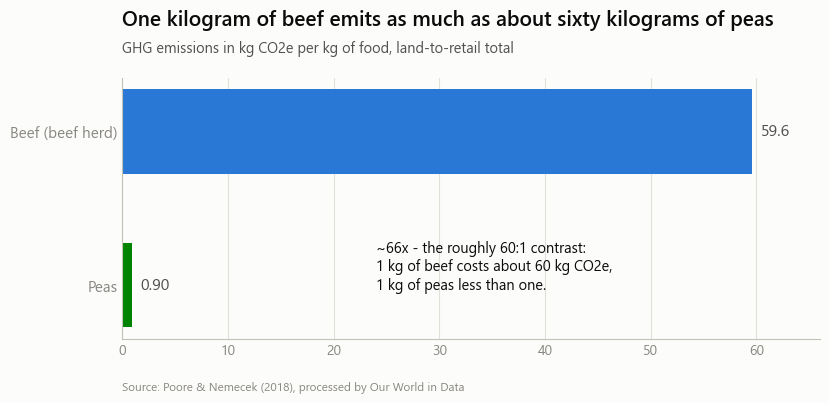

In [3]:
beef = perkg.loc[perkg['Food product'] == 'Beef (beef herd)', TOTAL].iloc[0]
peas = perkg.loc[perkg['Food product'] == 'Peas', TOTAL].iloc[0]
ratio = beef / peas

beef_avg = perkg.loc[perkg['Food product'] == 'Beef (beef herd)', AVG].iloc[0]
peas_avg = perkg.loc[perkg['Food product'] == 'Peas', AVG].iloc[0]
ratio_avg = beef_avg / peas_avg

print(f'Land-to-retail: beef {beef:.2f} vs peas {peas:.3f} kg CO2e/kg -> {ratio:.1f}x')
print(f'Total global average: beef {beef_avg:.2f} vs peas {peas_avg:.2f} -> {ratio_avg:.1f}x')

fig, ax = plt.subplots(figsize=(9, 3.4))
foods = ['Peas', 'Beef (beef herd)']          # beef ends up on top
vals = [peas, beef]
ax.barh(foods, vals, height=0.55, color=[GREEN, BLUE])

for y, v in enumerate(vals):
    ax.text(v + 0.8, y, fmt(v), va='center', ha='left', fontsize=11.5, color=SEC)

ax.annotate('~66x - the roughly 60:1 contrast:\n'
            '1 kg of beef costs about 60 kg CO2e,\n'
            '1 kg of peas less than one.',
            xy=(24, 0.12), fontsize=10.5, color=INK, ha='left', va='center')

style_axes(ax)
ax.set_xlim(0, 66)
ax.set_xticks(range(0, 70, 10))
ax.tick_params(axis='y', labelsize=11)

add_titles(ax,
           'One kilogram of beef emits as much as about sixty kilograms of peas',
           'GHG emissions in kg CO2e per kg of food, land-to-retail total',
           'Source: Poore & Nemecek (2018), processed by Our World in Data',
           source_pts=-30)

fig.savefig(FIGS / 'fig_slide02_beef_vs_peas.png',
            dpi=200, bbox_inches='tight', facecolor=SURFACE)
plt.show()


**Takeaway.** On the land-to-retail basis, Beef (beef herd) emits **59.57 kg CO2e per kg**
against **0.896** for Peas - a ratio of **66.5x**, the "roughly 60:1" contrast the deck
opens with. Put differently: producing a single kilogram of beef emits about as much as
sixty kilograms of peas, and one kilogram of beef is roughly 60 kg of CO2e on its own.

*Footnote:* on the "Total Global Average" column - which additionally counts post-retail
(consumer-stage) losses - beef is 99.48 vs 0.98 for peas, a ratio of about **100:1**.
We stay on the land-to-retail basis throughout because it is the conservative figure and
matches the stage columns the later stacked analyses use.


## Slide 4 - the full spread: all 43 foods per kg

The hook generalizes: ranking all 43 foods by the land-to-retail total shows how wide the
per-kg spread is and where the animal/plant line runs. One measure, ranked bars; color
carries only the animal/plant category (legend present, two categories). Value labels are
placed selectively on the foods the deck talks about - not on every bar of a 43-bar chart.


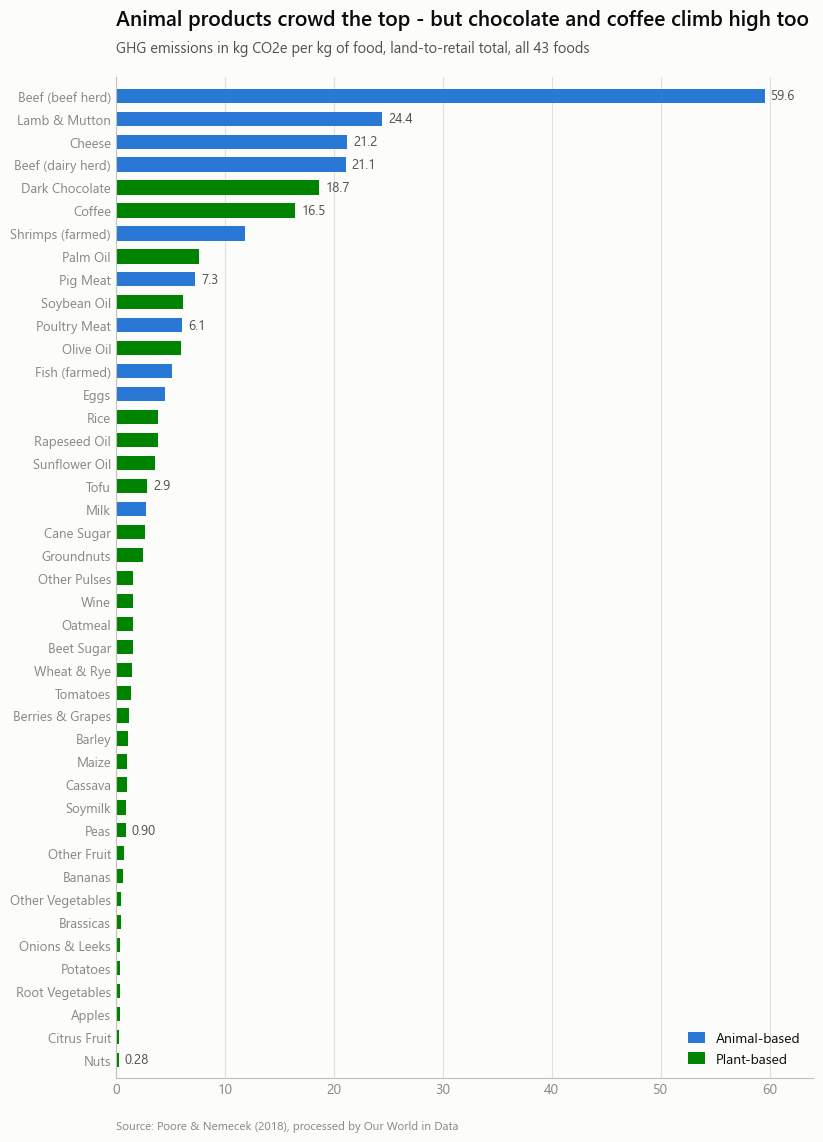

Spread: Nuts 0.278 to Beef (beef herd) 59.57 kg CO2e/kg -> 214x
     Food product     Category  Total from Land to Retail
 Beef (beef herd) Animal-based                     59.570
    Lamb & Mutton Animal-based                     24.415
           Cheese Animal-based                     21.240
Beef (dairy herd) Animal-based                     21.085
   Dark Chocolate  Plant-based                     18.681
           Coffee  Plant-based                     16.477


In [4]:
d = perkg.sort_values(TOTAL, ascending=True).reset_index(drop=True)  # largest ends on top
colors = [BLUE if f in ANIMAL else GREEN for f in d['Food product']]

STORY4 = {'Beef (beef herd)', 'Lamb & Mutton', 'Cheese', 'Beef (dairy herd)',
          'Dark Chocolate', 'Coffee', 'Poultry Meat', 'Pig Meat', 'Tofu',
          'Peas', 'Nuts'}

fig, ax = plt.subplots(figsize=(9, 13))
ax.barh(d['Food product'], d[TOTAL], height=0.62, color=colors)

for y, (f, v) in enumerate(zip(d['Food product'], d[TOTAL])):
    if f in STORY4:
        ax.text(v + 0.55, y, fmt(v), va='center', ha='left', fontsize=9.5, color=SEC)

style_axes(ax)
ax.set_xlim(0, 64)
ax.set_xticks(range(0, 70, 10))
ax.set_ylim(-0.8, len(d) - 0.2)
ax.tick_params(axis='y', labelsize=9.5)
cat_legend(ax, loc='lower right')

add_titles(ax,
           'Animal products crowd the top - but chocolate and coffee climb high too',
           'GHG emissions in kg CO2e per kg of food, land-to-retail total, all 43 foods',
           'Source: Poore & Nemecek (2018), processed by Our World in Data',
           source_pts=-30)

fig.savefig(FIGS / 'fig_slide04_perkg_spread.png',
            dpi=200, bbox_inches='tight', facecolor=SURFACE)
plt.show()

spread = d[TOTAL].max() / d[TOTAL].min()
lo = d.iloc[0]; hi = d.iloc[-1]
print(f"Spread: {lo['Food product']} {lo[TOTAL]:.3f} to {hi['Food product']} "
      f"{hi[TOTAL]:.2f} kg CO2e/kg -> {spread:.0f}x")
print(d.sort_values(TOTAL, ascending=False)[['Food product', 'Category', TOTAL]]
      .head(6).to_string(index=False))


**Takeaway.** The top of the chart is dominated by animal products - Beef (beef herd)
59.57, Lamb & Mutton 24.4, Cheese 21.2, Beef (dairy herd) 21.1 kg CO2e per kg. **But the
next two places are plants:** Dark Chocolate (18.7) and Coffee (16.5) sit above Shrimps,
Pig Meat and Poultry Meat, driven largely by land-use change (deforestation for cocoa and
coffee). The animal/plant split is real but not the whole story - this is exactly the
tension the clustering notebook picks up later in the deck, where emission *profiles*
rather than totals group the foods.

The spread is enormous: from Nuts at **0.278** to beef at **59.57** kg CO2e per kg -
a factor of **214x, i.e. more than 200x** between the least and most emitting food.


## Slide 5 - the fair comparison: emissions per 100 g of protein

Per-kg comparisons flatter watery, low-nutrition foods and punish dense ones. Since the
deck's dietary argument is about *protein* sources, slide 5 re-bases the comparison on
**kg CO2e per 100 g of protein** (Poore & Nemecek, reference year 2010).

**Filter rule.** We keep only genuine protein sources - foods eaten primarily for
protein or contributing meaningful protein to diets: the ten animal products plus Tofu,
Peas, Other Pulses, Groundnuts, Nuts, Grains, Wheat & Rye, Oatmeal, Maize and Rice
(20 foods). Without this filter the metric produces artifacts: **Dark Chocolate reads
93.3 kg CO2e per 100 g protein - the worst of ALL foods** - purely because chocolate
contains almost no protein, so the denominator collapses. The same artifact puts
Coffee at 35.7 and Tomatoes at 19.0. Nobody eats chocolate, coffee or tomatoes for
protein, so ranking them on a per-protein basis is meaningless; we report these numbers
as an appendix note instead (printed below the chart).


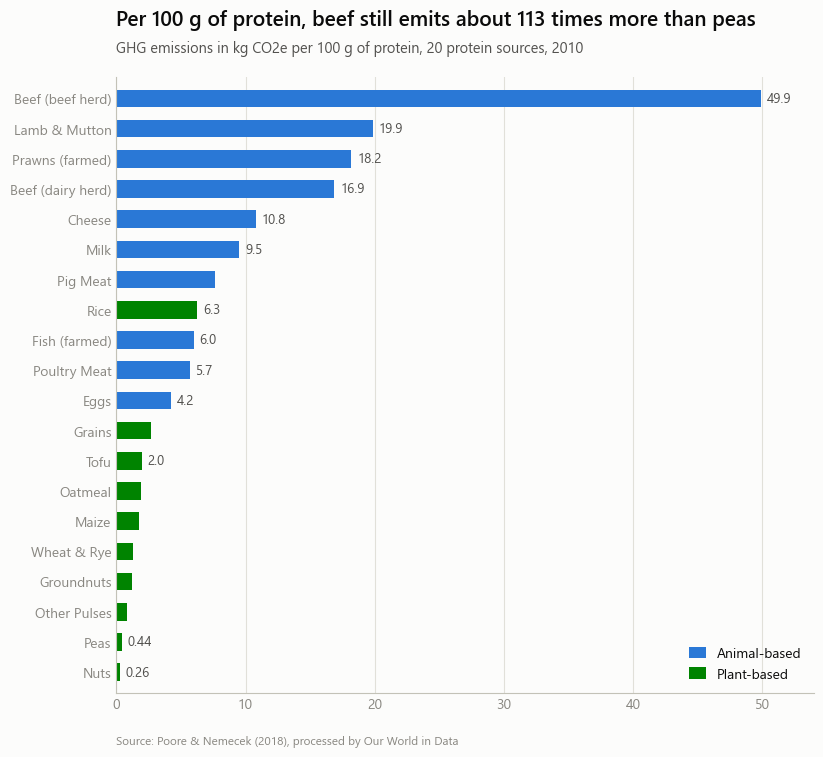

Per-protein beef:peas ratio = 49.9 / 0.44 = 113x

Appendix - the artifact the filter avoids (excluded foods, worst first):
          Entity  Greenhouse gas emissions per 100g protein
  Dark Chocolate                                  93.300000
          Coffee                                  35.662500
        Tomatoes                                  19.000000
Berries & Grapes                                  15.300000
         Cassava                                  14.666667


In [5]:
prot = pd.read_csv(DATA / 'ghg-per-protein-poore.csv')
PCOL = 'Greenhouse gas emissions per 100g protein'

PROTEIN_FOODS = ['Beef (beef herd)', 'Beef (dairy herd)', 'Lamb & Mutton', 'Pig Meat',
                 'Poultry Meat', 'Fish (farmed)', 'Prawns (farmed)', 'Eggs', 'Milk',
                 'Cheese', 'Tofu', 'Peas', 'Other Pulses', 'Groundnuts', 'Nuts',
                 'Grains', 'Wheat & Rye', 'Oatmeal', 'Maize', 'Rice']

pf = prot[prot['Entity'].isin(PROTEIN_FOODS)].copy()
assert len(pf) == 20, f'expected 20 protein sources, got {len(pf)}'

# 'Prawns (farmed)' is the per-protein file's name for 'Shrimps (farmed)' - animal-based.
ANIMAL_P = ANIMAL | {'Prawns (farmed)'}
pf['Category'] = np.where(pf['Entity'].isin(ANIMAL_P), 'Animal-based', 'Plant-based')

pf = pf.sort_values(PCOL, ascending=True).reset_index(drop=True)  # largest ends on top
colors = [BLUE if c == 'Animal-based' else GREEN for c in pf['Category']]

STORY5 = {'Beef (beef herd)', 'Lamb & Mutton', 'Prawns (farmed)', 'Beef (dairy herd)',
          'Cheese', 'Milk', 'Rice', 'Poultry Meat', 'Fish (farmed)', 'Eggs',
          'Tofu', 'Peas', 'Nuts'}

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(pf['Entity'], pf[PCOL], height=0.58, color=colors)

for y, (f, v) in enumerate(zip(pf['Entity'], pf[PCOL])):
    if f in STORY5:
        ax.text(v + 0.45, y, fmt(v), va='center', ha='left', fontsize=9.5, color=SEC)

style_axes(ax)
ax.set_xlim(0, 54)
ax.set_xticks(range(0, 60, 10))
ax.set_ylim(-0.7, len(pf) - 0.3)
ax.tick_params(axis='y', labelsize=10)
cat_legend(ax, loc='lower right')

add_titles(ax,
           'Per 100 g of protein, beef still emits about 113 times more than peas',
           'GHG emissions in kg CO2e per 100 g of protein, 20 protein sources, 2010',
           'Source: Poore & Nemecek (2018), processed by Our World in Data',
           source_pts=-30)

fig.savefig(FIGS / 'fig_slide05_per_protein.png',
            dpi=200, bbox_inches='tight', facecolor=SURFACE)
plt.show()

b = pf.loc[pf['Entity'] == 'Beef (beef herd)', PCOL].iloc[0]
p = pf.loc[pf['Entity'] == 'Peas', PCOL].iloc[0]
print(f'Per-protein beef:peas ratio = {b:.1f} / {p:.2f} = {b / p:.0f}x')

print('\nAppendix - the artifact the filter avoids (excluded foods, worst first):')
excl = prot[~prot['Entity'].isin(PROTEIN_FOODS)].sort_values(PCOL, ascending=False)
print(excl[['Entity', PCOL]].head(5).to_string(index=False))


**Takeaway.** The fair comparison makes beef look *worse*, not better. Per 100 g of
protein, Beef (beef herd) emits **49.9 kg CO2e** against **0.44** for Peas - a ratio of
about **113:1**, steeper than the 66:1 per-kg contrast. The animal block still owns the
top: lamb 19.9, prawns 18.2, beef (dairy herd) 16.9, cheese 10.8, milk 9.5. The cheapest
proteins are plants - nuts 0.26, peas 0.44, pulses 0.84 - while the best animal options
(eggs 4.2, poultry 5.7, fish 6.0) land mid-table. Rice, at 6.3, is the one plant staple
that ranks *worse* than poultry and farmed fish on this basis - protein-poor grains pay
a penalty when protein is the yardstick.


### The rank flip: what changes when the basis changes

To show *which* foods move when we switch from per-kg to per-protein, we join the two
files on food name ("Prawns (farmed)" in the per-protein file maps to "Shrimps (farmed)"
in the per-kg file; "Grains" has no per-kg counterpart, so it is excluded from the join
but stays in the main chart above). For the **19** protein sources present in both files
we rank each basis from 1 = highest emissions and connect the two ranks with a slope line.


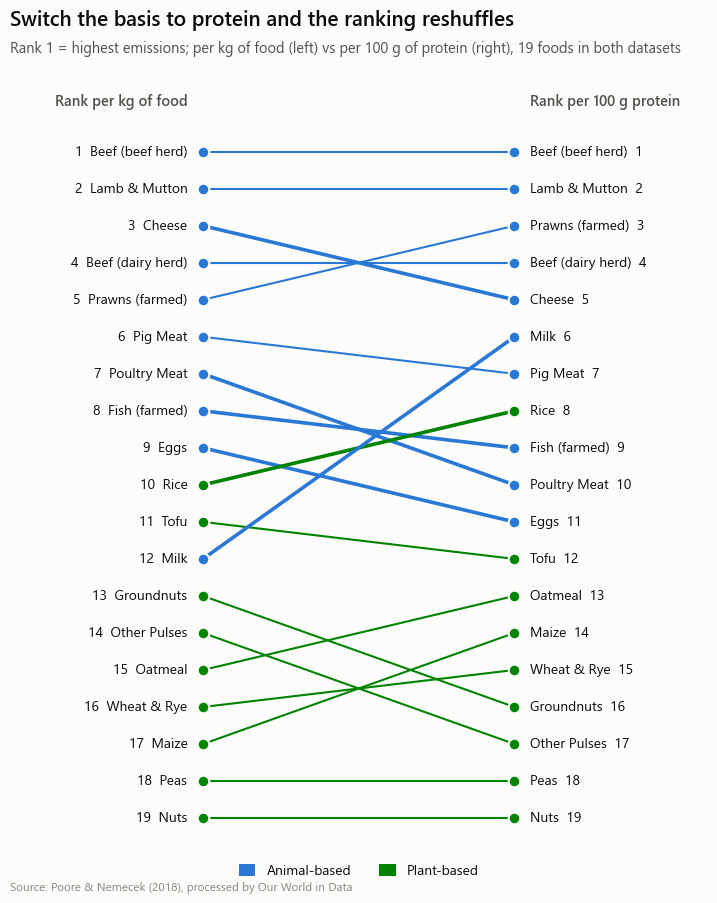

           Entity  rank_kg  rank_prot  shift
       Groundnuts       13         16     -3
     Other Pulses       14         17     -3
     Poultry Meat        7         10     -3
             Eggs        9         11     -2
           Cheese        3          5     -2
    Fish (farmed)        8          9     -1
             Tofu       11         12     -1
         Pig Meat        6          7     -1
             Peas       18         18      0
Beef (dairy herd)        4          4      0
             Nuts       19         19      0
    Lamb & Mutton        2          2      0
 Beef (beef herd)        1          1      0
      Wheat & Rye       16         15      1
             Rice       10          8      2
          Oatmeal       15         13      2
  Prawns (farmed)        5          3      2
            Maize       17         14      3
             Milk       12          6      6


In [6]:
name_map = {'Prawns (farmed)': 'Shrimps (farmed)'}

j = pf[pf['Entity'] != 'Grains'].copy()           # Grains: per-protein file only
j['perkg_name'] = j['Entity'].replace(name_map)
j = j.merge(perkg[['Food product', TOTAL]], left_on='perkg_name', right_on='Food product')
assert len(j) == 19, f'expected 19 joined foods, got {len(j)}'

j['rank_kg'] = j[TOTAL].rank(ascending=False).astype(int)      # 1 = worst per kg
j['rank_prot'] = j[PCOL].rank(ascending=False).astype(int)     # 1 = worst per protein

FLIPS = {'Cheese', 'Milk', 'Rice', 'Eggs', 'Poultry Meat', 'Fish (farmed)'}

fig, ax = plt.subplots(figsize=(9, 10))
for _, r in j.iterrows():
    c = BLUE if r['Category'] == 'Animal-based' else GREEN
    lw = 2.6 if r['Entity'] in FLIPS else 1.5
    ax.plot([0, 1], [r['rank_kg'], r['rank_prot']], color=c, lw=lw, zorder=2)
    ax.scatter([0, 1], [r['rank_kg'], r['rank_prot']], s=70, color=c,
               edgecolor=SURFACE, linewidth=1.5, zorder=3)
    ax.text(-0.05, r['rank_kg'], f"{r['rank_kg']}  {r['Entity']}",
            ha='right', va='center', fontsize=10, color=INK)
    ax.text(1.05, r['rank_prot'], f"{r['Entity']}  {r['rank_prot']}",
            ha='left', va='center', fontsize=10, color=INK)

ax.text(-0.05, -0.35, 'Rank per kg of food', ha='right', va='center',
        fontsize=10.5, color=SEC, fontweight=600)
ax.text(1.05, -0.35, 'Rank per 100 g protein', ha='left', va='center',
        fontsize=10.5, color=SEC, fontweight=600)

ax.set_xlim(-0.62, 1.62)
ax.set_ylim(19.8, -1.0)                     # rank 1 on top
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)

handles = [Patch(facecolor=BLUE, label='Animal-based'),
           Patch(facecolor=GREEN, label='Plant-based')]
ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.005),
          ncols=2, fontsize=10, labelcolor=INK, handlelength=1.2, handleheight=0.9)

add_titles(ax,
           'Switch the basis to protein and the ranking reshuffles',
           'Rank 1 = highest emissions; per kg of food (left) vs per 100 g of protein '
           '(right), 19 foods in both datasets',
           'Source: Poore & Nemecek (2018), processed by Our World in Data',
           source_pts=-24)

fig.savefig(FIGS / 'fig_slide05_rank_flip.png',
            dpi=200, bbox_inches='tight', facecolor=SURFACE)
plt.show()

moves = j[['Entity', 'rank_kg', 'rank_prot']].copy()
moves['shift'] = moves['rank_kg'] - moves['rank_prot']   # + means worse per protein
print(moves.sort_values('shift')[['Entity', 'rank_kg', 'rank_prot', 'shift']]
      .to_string(index=False))


**Takeaway.** The slope lines expose the flips the per-kg chart hides:

- **Cheese drops below Beef (dairy herd)**: per kg, cheese ranks 3rd (worse than dairy-herd
  beef at 4th); per protein it falls to 5th, behind both dairy-herd beef (4th) and prawns
  (3rd). Cheese is protein-dense, so the protein basis is kinder to it.
- **Milk moves the other way** - from 12th per kg to 6th per protein: it is mostly water,
  so per-protein it becomes one of the more expensive foods.
- **Rice ranks worse than poultry and farmed fish per protein** (rice 8th vs fish 9th and
  poultry 10th) despite being far cheaper per kg (10th vs 7th and 8th) - low protein
  density costs it dearly.
- **Eggs, poultry and fish beat dairy**: at 4.2, 5.7 and 6.0 kg CO2e per 100 g protein
  they all undercut milk (9.5) and cheese (10.8).

The ordering of the extremes, though, is basis-proof: ruminant meat at the top, pulses
and nuts at the bottom, on either yardstick.


## Limitations

- **Global averages.** Every number is a global mean across thousands of farms; regional
  and producer-level variation is large (the original study reports wide percentile
  ranges). A specific beef supply chain can sit far from 59.57.
- **Sample size.** The per-kg file covers 43 foods, the per-protein file 32; they are
  aggregate commodity categories, not individual products.
- **Reference year.** The per-protein figures carry a 2010 reference year; production
  practices have shifted since.
- **Basis choice.** We standardize on the land-to-retail total, which excludes
  post-retail (consumer) losses; on the "Total Global Average" column the headline
  beef:peas ratio widens from ~66:1 to ~100:1. Our choice is the conservative one.
- **Protein filter.** The 20-food "genuine protein source" list is a judgment call; it is
  stated explicitly above so it can be challenged, and the excluded foods' per-protein
  values are printed as an appendix note.


## Sources

- Poore, J., & Nemecek, T. (2018). Reducing food's environmental impacts through
  producers and consumers. *Science*, 360(6392), 987-992.
- Our World in Data - "Environmental Impacts of Food Production" (processed versions of
  the Poore & Nemecek data): per-kg supply-chain stage emissions and GHG emissions per
  100 g of protein (reference year 2010).
